# EDA on AirBnb

### Objective

The goal of this analysis is to perform a comprehensive **Exploratory Data Analysis (EDA)** on the New York City Airbnb dataset (2019). We aim to:

* Identify geographical price hotspots.

* Analyze the relationship between room types and availability.

* Uncover patterns in host behavior and customer reviews.

### Tasks

1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Univariate, Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

## Technologies Used

**Tools & Libraries:** Python (Pandas, Numpy)

* **Visualization:** Matplotlib, Seaborn

* **Environment:** Google Colab / Jupyter Notebooks

## 1.Data Loading

#### **Data Dictionary**
| Column | Description |
| :--- | :--- |
| **id** | Unique identifier for the listing |
| **neighbourhood_group** | The five boroughs of NYC (Manhattan, Brooklyn, etc.) |
| **room_type** | Type of listing (Entire home, Private room, Shared room) |
| **calculated_host_listings_count** | Amount of listings the host has |
| **availability_365** | Number of days the listing is available for booking in a year |

In [2]:
# importing neccessary Libraries
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Loading the Dataset
data = pd.read_csv('data/AB_NYC_2019.csv')

#### Initial Analysis

In [4]:
data.shape

(48895, 16)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
# null values check
data.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [7]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 2.Data Cleaning

In this phase, we address missing values, duplicates, and outliers to ensure the integrity of our analysis.  






#### 2.1 Handling Missing Values
* **`reviews_per_month`**: Imputed with `0` as a missing value here logically implies the listing has received zero reviews.
* **`last_review`**: Converted to `datetime` format. Remaining nulls are kept as `NaT` (Not a Time) to avoid injecting fake dates into the timeline.
* **`name` & `host_name`**: Dropped due to high cardinality and low analytical value for this specific scope.

In [8]:
# Droping the Name and Host name column - as it have high cardinality and it doesn't have impact on analysis
data.drop(columns=['name','host_name'],axis=1,inplace=True)

In [9]:
data.isnull().sum()/len(data)*100

,0
id,0.000000
host_id,0.000000
neighbourhood_group,0.000000
neighbourhood,0.000000
latitude,0.000000
longitude,0.000000
room_type,0.000000
price,0.000000
minimum_nights,0.000000
number_of_reviews,0.000000


In [10]:
# rows with missing values
data[data.isnull().any(axis=1)].head()

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
19,7750,17985,Manhattan,East Harlem,40.79685,-73.94872,Entire home/apt,190,7,0,NaN,NaN,2,249
26,8700,26394,Manhattan,Inwood,40.86754,-73.92639,Private room,80,4,0,NaN,NaN,1,0
36,11452,7355,Brooklyn,Bedford-Stuyvesant,40.68876,-73.94312,Private room,35,60,0,NaN,NaN,1,365
38,11943,45445,Brooklyn,Flatbush,40.63702,-73.96327,Private room,150,1,0,NaN,NaN,1,365


From the rows with missing values - its clear that reviews per month and last review, both the columns are missing for same set of rows

In [11]:
# imputing reviews per month with zero - as it implies no review
data.fillna(0,inplace=True)

In [12]:
# Converting last_review column to type date and imputing it with NaT
data.last_review = pd.to_datetime(data.last_review,errors='coerce')

In [13]:
data[data.isnull().any(axis=1)].head()

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.0,1,365
19,7750,17985,Manhattan,East Harlem,40.79685,-73.94872,Entire home/apt,190,7,0,NaT,0.0,2,249
26,8700,26394,Manhattan,Inwood,40.86754,-73.92639,Private room,80,4,0,NaT,0.0,1,0
36,11452,7355,Brooklyn,Bedford-Stuyvesant,40.68876,-73.94312,Private room,35,60,0,NaT,0.0,1,365
38,11943,45445,Brooklyn,Flatbush,40.63702,-73.96327,Private room,150,1,0,NaT,0.0,1,365


In [14]:
data.columns

Index(['id', 'host_id', 'neighbourhood_group', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

#### 2.2 Handling Duplicates

* No duplicate records were found

In [15]:
# No dupplicate rows
data.duplicated().sum()

np.int64(0)

In [16]:
# id column is also unique
data.duplicated(subset='id').sum()

np.int64(0)

In [17]:
data.id.is_unique

True

#### 2.3 Outlier Management
To prevent extreme values from skewing our statistical distributions, we applied the following filters:
> * **Minimum Nights**: Removed listings requiring > 800 nights.
> * **Reviews per Month**: Removed listings with > 25 reviews/month (potential data entry errors).
> * **Note on Price**: High-end price outliers were **retained** to represent the luxury market segment.

In [18]:
data.columns

Index(['id', 'host_id', 'neighbourhood_group', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [19]:
# creating list of caegorical columns
cat_col = []


In [20]:
data.neighbourhood_group.value_counts()
cat_col.append('neighbourhood_group')
# cat_col
data.neighbourhood.value_counts()
cat_col.append('neighbourhood')

data.room_type.value_counts()
cat_col.append('room_type')

# final cat_col list
cat_col

['neighbourhood_group', 'neighbourhood', 'room_type']

In [21]:
num_col = ['latitude','longitude','price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']

In [22]:
data[num_col].describe(percentiles=[0.01,0.25,0.50,0.75,0.99])

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
1%,40.596687,-74.026774,30.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
99%,40.864661,-73.776920,799.000000,45.000000,214.000000,6.800000,232.000000,365.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


<Axes: >

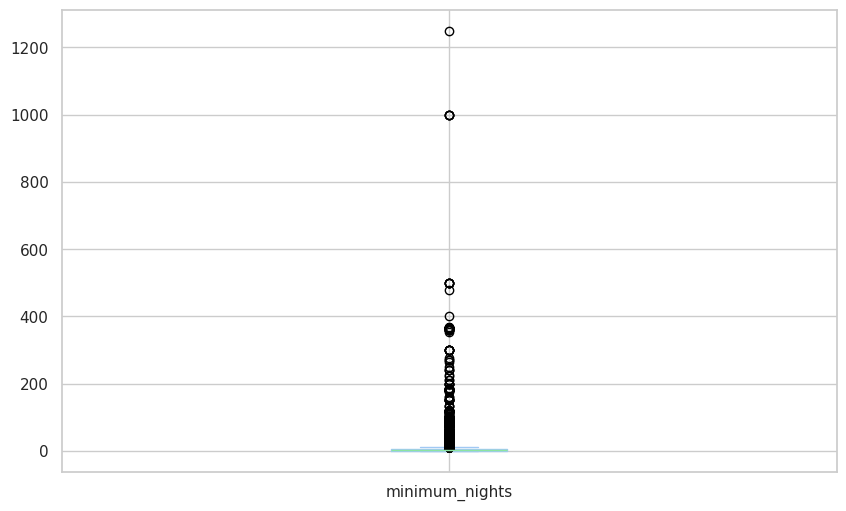

In [23]:
data.minimum_nights.plot.box()

In [24]:
# above 800 is significantly away from other points hence removing them
data = data[data.minimum_nights < 800]

<Axes: >

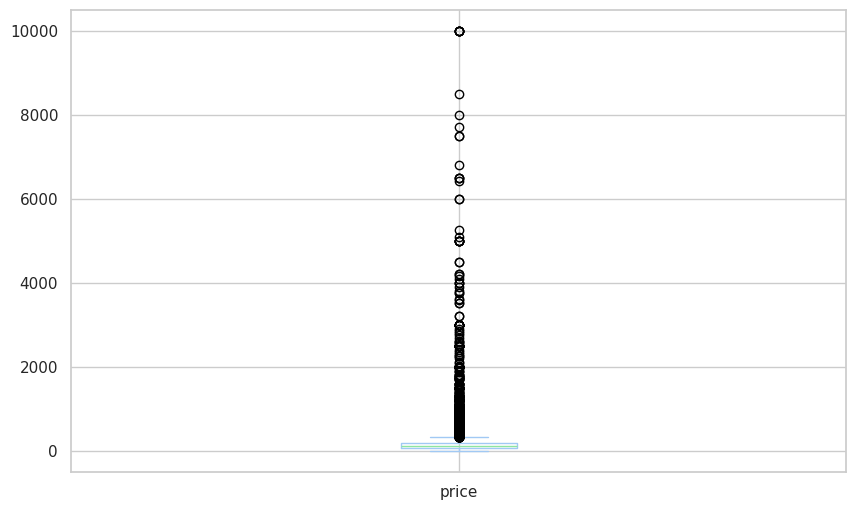

In [25]:
data.price.plot.box()
# 99% of price is below 799 - But we're keeping the outliers as this might be a valid data, because its possible to have luxury options

<Axes: >

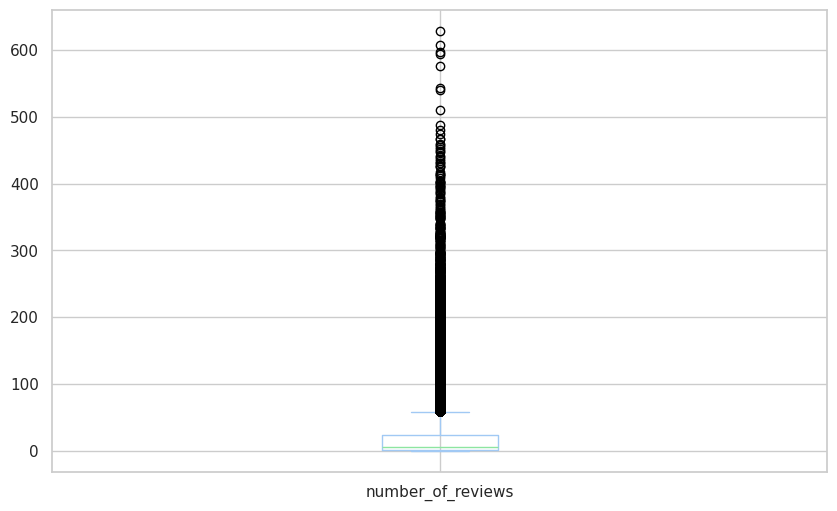

In [26]:
data.number_of_reviews.plot.box()
# Keeping number of reviews as its important

<Axes: >

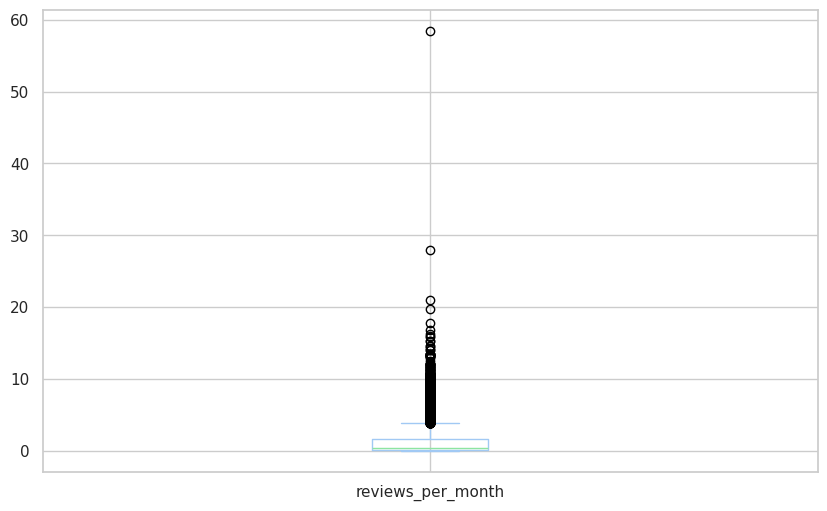

In [27]:
data.reviews_per_month.plot.box()

In [28]:
data[data.reviews_per_month>25]

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
42075,32678719,244361589,Manhattan,Theater District,40.75918,-73.98801,Private room,100,1,156,2019-07-07,58.50,9,299
42076,32678720,244361589,Manhattan,Theater District,40.75828,-73.98876,Private room,199,1,82,2019-07-07,27.95,9,299


In [29]:
# since 2 of them are away - removing those
data = data[data.reviews_per_month < 25]

<Axes: >

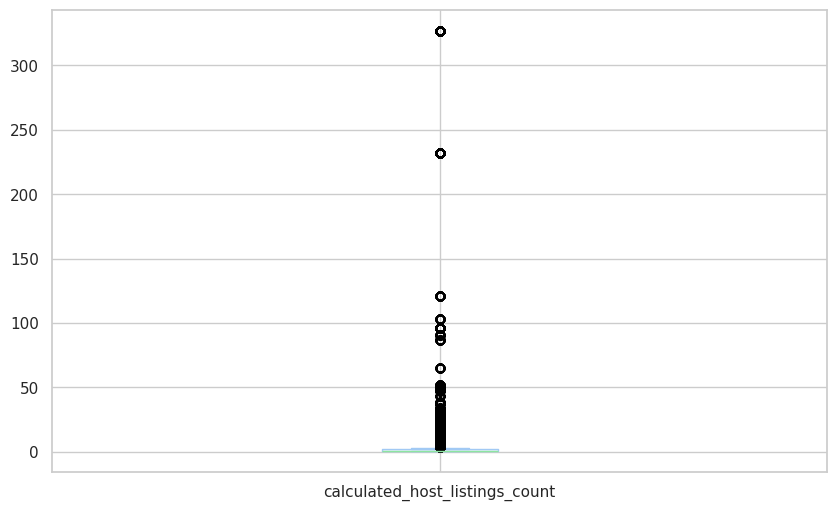

In [30]:
data.calculated_host_listings_count.plot.box()

<Axes: xlabel='calculated_host_listings_count', ylabel='Density'>

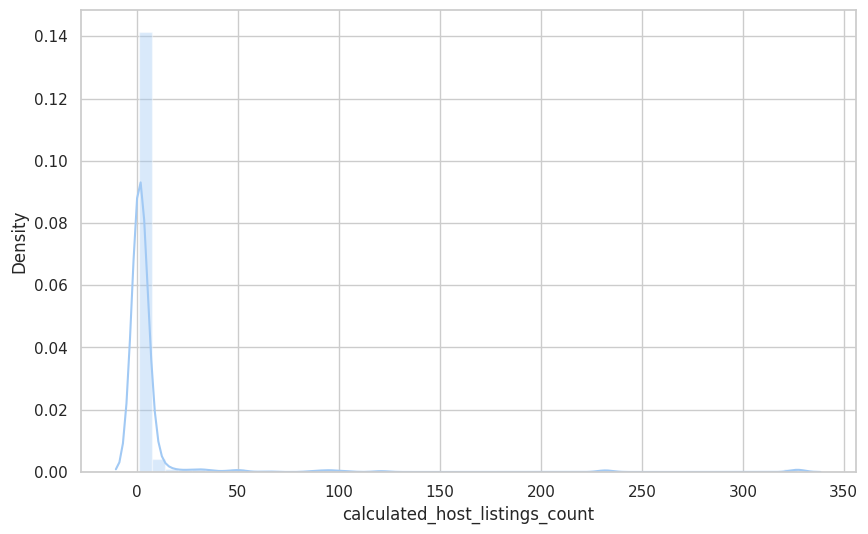

In [31]:
plt.figure(figsize=(10,6))
sns.distplot(data.calculated_host_listings_count,bins=50)

In [32]:
data[data.calculated_host_listings_count>150]
# keeping them as its possible to have host having large number of properties

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
26137,20845031,107434423,Manhattan,Kips Bay,40.74510,-73.97915,Entire home/apt,308,30,0,NaT,0.00,232,156
29128,22370388,107434423,Manhattan,Financial District,40.70637,-74.00941,Entire home/apt,271,30,1,2018-08-17,0.09,232,310
30158,23264421,107434423,Manhattan,Murray Hill,40.74900,-73.97961,Entire home/apt,289,30,0,NaT,0.00,232,223
30428,23538486,107434423,Manhattan,Murray Hill,40.74891,-73.97887,Entire home/apt,305,30,1,2019-01-15,0.17,232,326
31506,24535218,107434423,Manhattan,Tribeca,40.71433,-74.01073,Entire home/apt,323,30,0,NaT,0.00,232,316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48723,36404684,107434423,Manhattan,Nolita,40.72283,-73.99472,Entire home/apt,316,30,0,NaT,0.00,232,325
48724,36404784,107434423,Manhattan,Hell's Kitchen,40.76082,-73.99709,Entire home/apt,385,30,0,NaT,0.00,232,338
48725,36404815,107434423,Manhattan,Hell's Kitchen,40.76083,-73.99727,Entire home/apt,267,30,0,NaT,0.00,232,228
48726,36404936,107434423,Brooklyn,Williamsburg,40.71493,-73.96365,Entire home/apt,278,30,0,NaT,0.00,232,188


<Axes: >

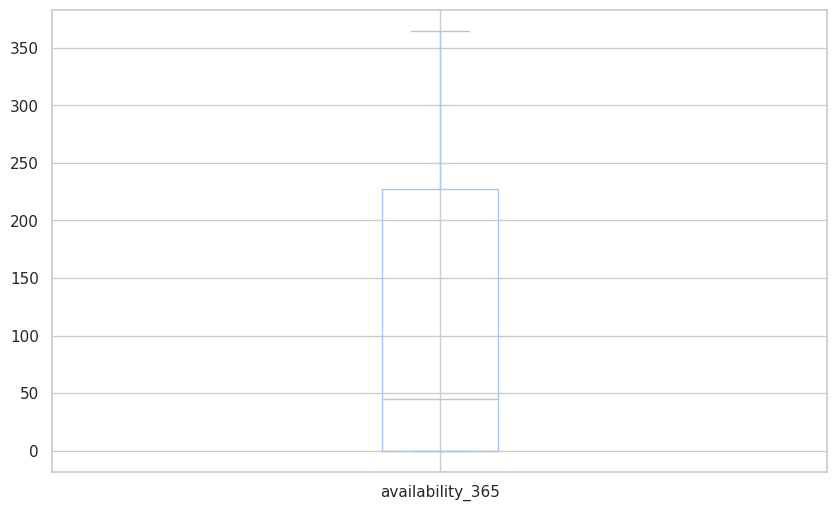

In [33]:
data.availability_365.plot.box()

**Insights:**



1.   Missing Values Handling  
      It is observed that only 2 columns have missing values and 20% of the values are missing.  
      It is not suggested to remove the missing rows hence we imputed the values.  
      Reviews_per_month column is filled with 0 assuming no reviews and last_review column missing values are left as-is since they won't impact the analysis.


2.   Handling Duplicates  
      No duplicate records were not found in the data.  
      In cas if any duplicates were found it should be removed to ensure data consistency

3.   Handling Outliers  
      Outliers from reviews_per_month and minimum_nights columns are removed and from proce and calculated_host_listings_count are retained to reflect real-world premium listings
  
    
      


Final dataset contains approximately 48,000 rows and 14 columns after cleaning.



The cleaned dataset is now ready for exploratory data analysis to uncover patterns and insights.

## 3.Exploratory Analysis

#### 3.1 Univariate

Text(0.5, 1.0, 'Price Distribution')

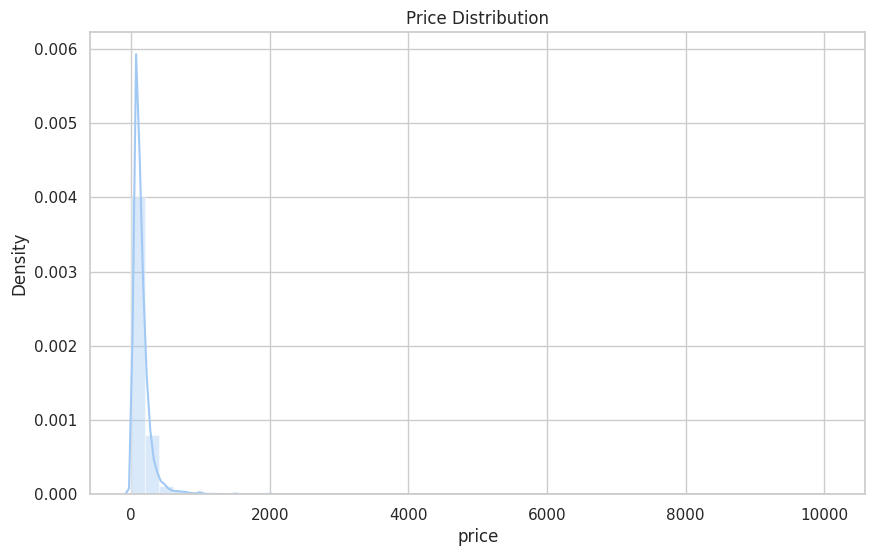

In [34]:
plt.figure(figsize=(10,6))
sns.distplot(data.price,bins=50)
plt.title('Price Distribution')

 **Analysis: Price Distribution**
* **Observation:** The distribution is heavily right-skewed, with a massive concentration of listings below \$200.
* **Outliers:** While luxury listings exist up to \$10,000, they represent a statistically small segment of the market.

> **Business Impact:** The NYC Airbnb market is fundamentally a "budget-to-mid-range" market. To achieve high occupancy, pricing should stay within the 25th-75th percentile ($69 - $175).

Text(0.5, 1.0, 'Room Type Distribution')

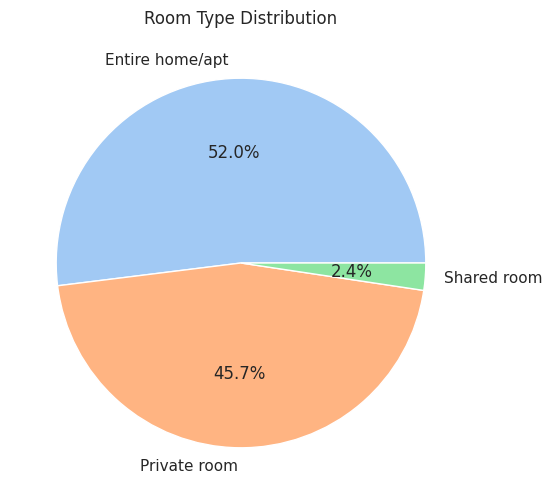

In [35]:
plt.figure(figsize=(10,6))
# sns.countplot(data=data,x='room_type',order=data.room_type.value_counts().index)
plt.pie(data.room_type.value_counts(),labels=data.room_type.value_counts().index,autopct='%1.1f%%')
plt.title('Room Type Distribution')


 **Analysis: Accommodation Preferences**
* **Observation:** **Entire homes/apartments (52%)** and **Private rooms (45.7%)** dominate the market, leaving shared rooms as a negligible <3% niche.
* **Strategic Value:** High demand for privacy indicates that travelers prioritize personal space over extreme cost-saving. Investors should avoid shared-room models in this market.

Text(0.5, 1.0, 'Neighbourhood Group Distribution')

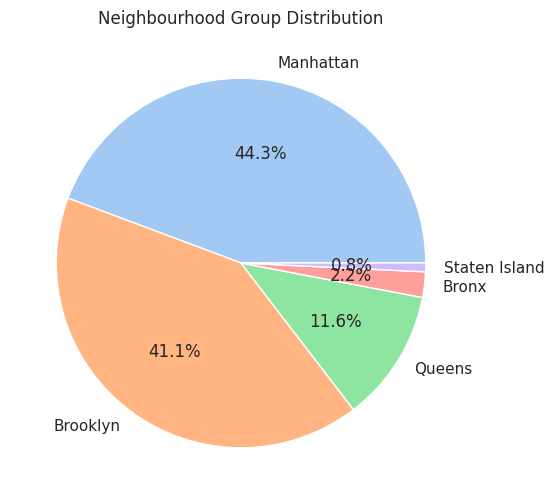

In [36]:
plt.figure(figsize=(10,6))
plt.pie(x=data.neighbourhood_group.value_counts(),labels=data.neighbourhood_group.value_counts().index,autopct='%1.1f%%')
plt.title('Neighbourhood Group Distribution')

 **Analysis: Borough Market Share**
* **Observation:** **Manhattan (44.3%)** and **Brooklyn (41.1%)** control over 85% of total NYC listings.
* **Strategic Value:** The market is highly centralized. While competition is fiercest in these two boroughs, they represent the "safe bets" for high-frequency bookings.

Text(0, 0.5, 'Count')

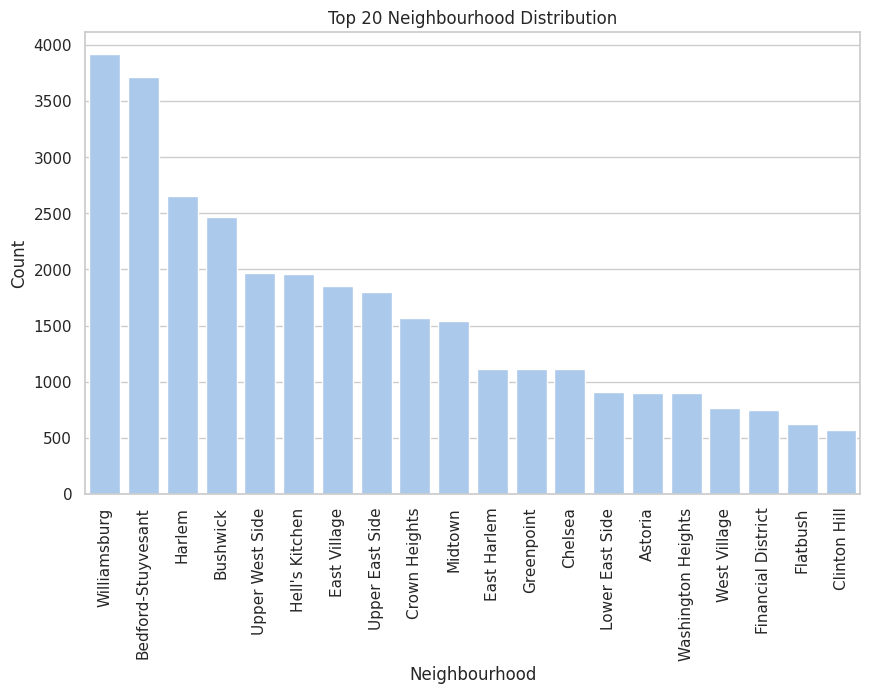

In [37]:
# Visualizing only top 20 regions

neighbourhood = data.neighbourhood.value_counts().index[:20]
neighbourhood
plt.figure(figsize=(10,6))
sns.countplot(data=data,x='neighbourhood',order=neighbourhood)
plt.title('Top 20 Neighbourhood Distribution')
plt.xlabel('Neighbourhood')
plt.xticks(rotation=90)
plt.ylabel('Count')



 **Analysis: Hyper-Local Hotspots**
* **Observation:** A small subset of neighbourhoods (Bedford-Stuyvesant, Williamsburg, Harlem) carries the bulk of the inventory.
* **Strategic Value:** These are established "Airbnb hubs." New entries here benefit from high organic search traffic but must differentiate through superior amenities or professional photography.

Text(0, 0.5, 'Count')

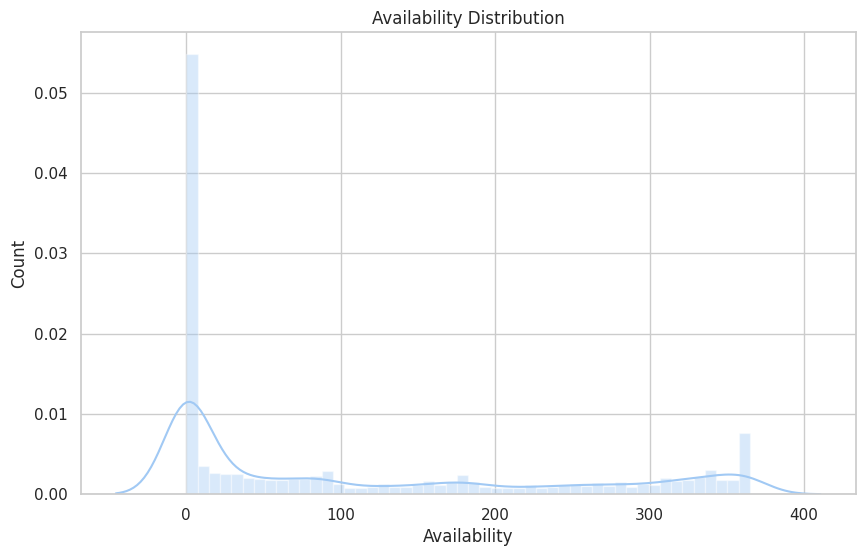

In [38]:
plt.figure(figsize=(10,6))
sns.distplot(data.availability_365,bins=50)
plt.title('Availability Distribution')
plt.xlabel('Availability')
plt.ylabel('Count')

Text(0.5, 0, 'Minimum Nights')

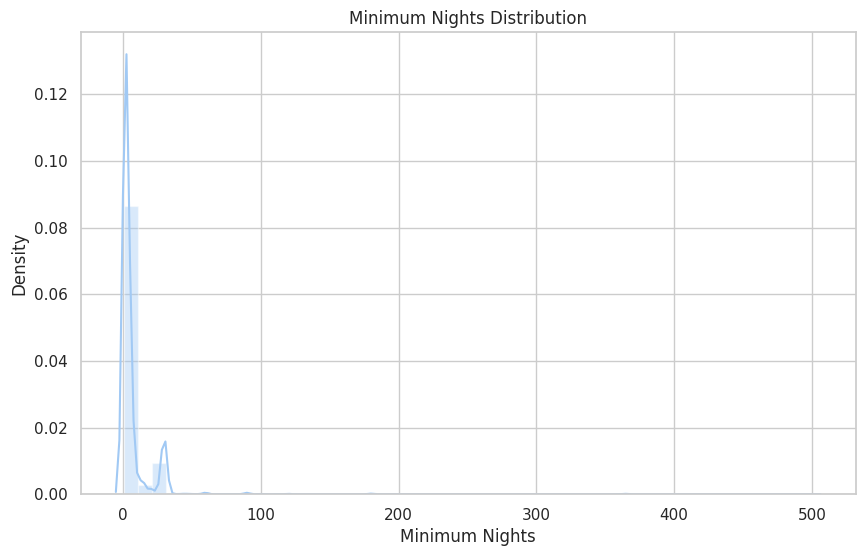

In [39]:
plt.figure(figsize=(10,6))
sns.distplot(data.minimum_nights,bins=50)
plt.title('Minimum Nights Distribution')
plt.xlabel('Minimum Nights')

 **Analysis: Booking Flexibility**
* **Availability:** The "U-shaped" distribution shows listings are either "Full-Time Business" (high availability) or "Casual/Rare" (low availability).
* **Minimum Nights:** A vast majority of hosts require **1–3 nights**, aligning with the typical weekend tourist profile.
* **Strategic Value:** Strict minimum-stay policies (>7 nights) significantly shrink the potential guest pool in the NYC ecosystem.

Text(0.5, 0, 'Review per month')

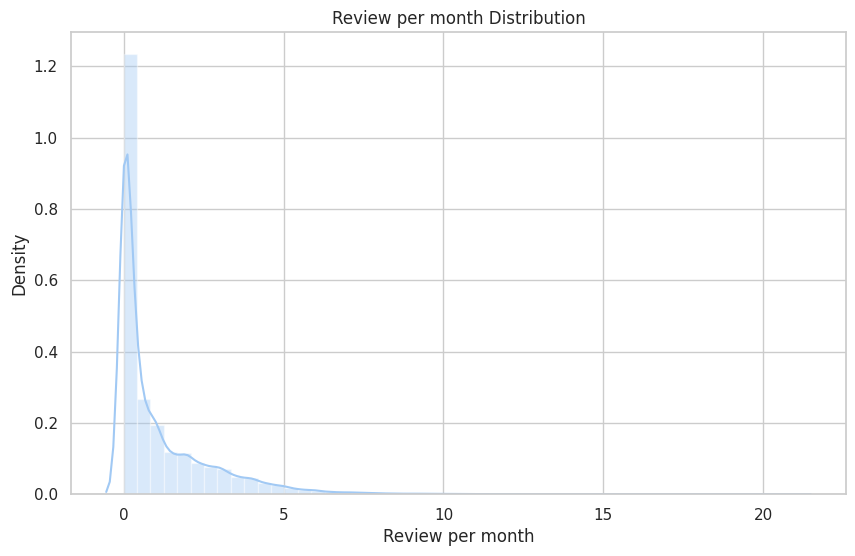

In [40]:
plt.figure(figsize=(10,6))
sns.distplot(data.reviews_per_month,bins=50)
plt.title('Review per month Distribution')
plt.xlabel('Review per month')

Text(0.5, 0, 'Number of Reviews')

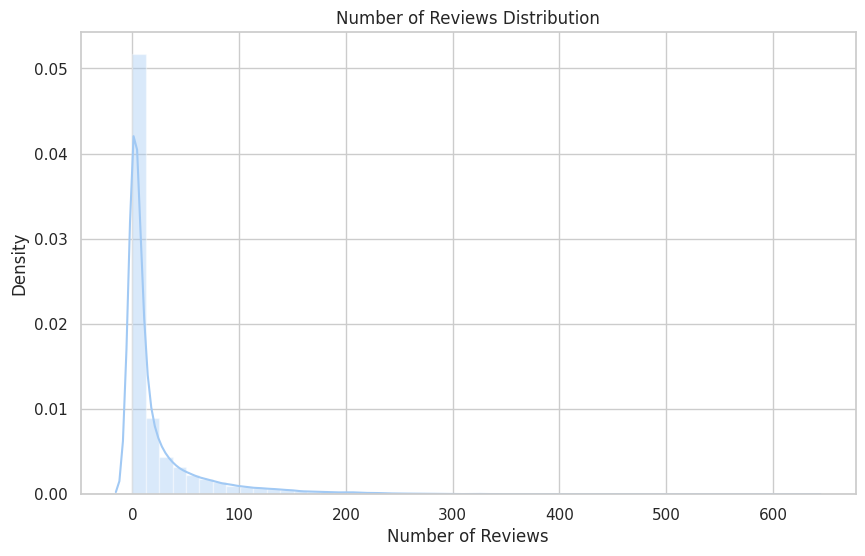

In [41]:
plt.figure(figsize=(10,6))
sns.distplot(data.number_of_reviews,bins=50)
plt.title('Number of Reviews Distribution')
plt.xlabel('Number of Reviews')

 **Analysis: Listing Engagement & Trust**
* **Observation:** Most listings have low review counts, while a "Power Law" applies to a few top-performing properties with 100+ reviews.
* **Strategic Value:** Reviews are the primary currency of trust. High review velocity (reviews per month) is a stronger indicator of a "healthy" business than the total count alone.

Text(0.5, 0, 'Calculated Host Listings Count')

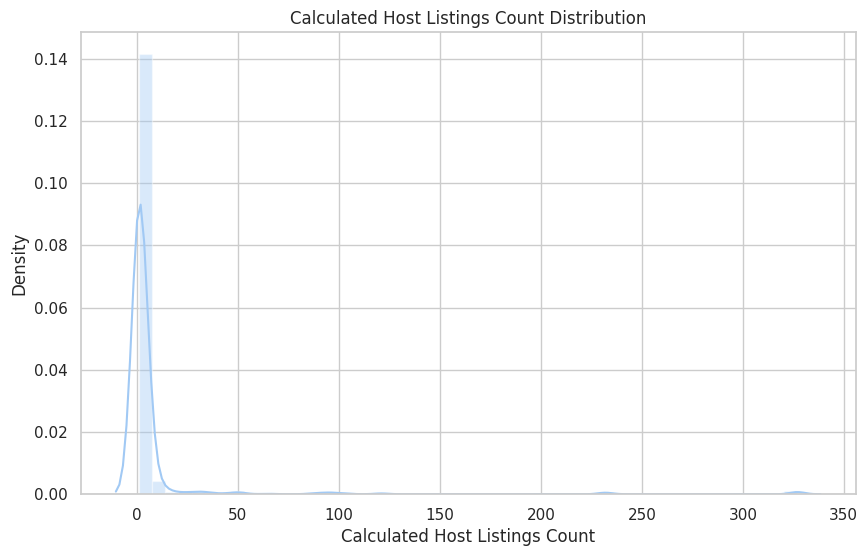

In [42]:
plt.figure(figsize=(10,6))
sns.distplot(data.calculated_host_listings_count,bins=50)
plt.title('Calculated Host Listings Count Distribution')
plt.xlabel('Calculated Host Listings Count')

 **Analysis: Host Ecosystem (Individual vs. Professional)**
* **Observation:** The distribution is dominated by a "Long Tail." Over 80% of hosts manage only a single listing, while a small group of "Power Hosts" manage 100+ properties.
* **Business Interpretation:** * **Casual Segment:** The platform remains a marketplace for individual homeowners.
    * **Commercial Segment:** Outliers with high listing counts represent property management firms or commercial operators.
    * **Market Health:** A high number of single-listing hosts suggests a more "authentic" Airbnb experience, which is a key marketing draw for the NYC area.

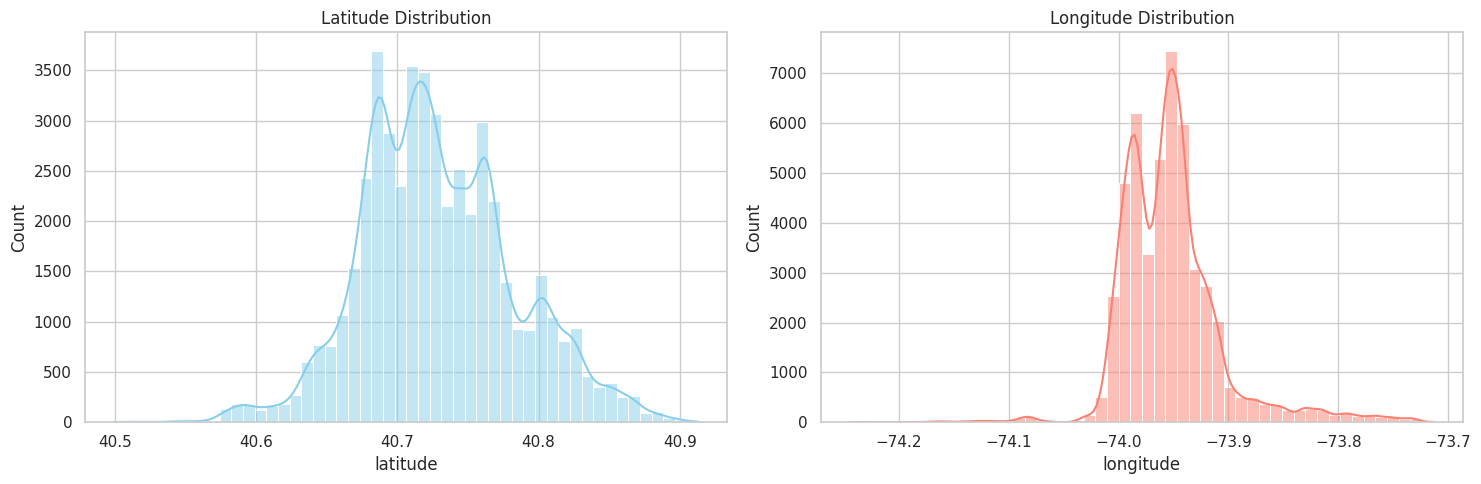

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data.latitude, bins=50, ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Latitude Distribution')

sns.histplot(data.longitude, bins=50, ax=axes[1], kde=True, color='salmon')
axes[1].set_title('Longitude Distribution')

plt.tight_layout()
plt.show()

In [44]:
data[['latitude','longitude']].describe()

,latitude,longitude
count,48888.000000,48888.000000
mean,40.728946,-73.952165
std,0.054532,0.046158
min,40.499790,-74.244420
25%,40.690090,-73.983070
50%,40.723070,-73.955680
75%,40.763120,-73.936270
max,40.913060,-73.712990


 **Analysis: Geographic Distribution**
* **Observation:** The density plots for Latitude and Longitude reveal a high concentration of listings in a very narrow coordinate range (centered around Central Park and North Brooklyn).
* **Strategic Value:** This confirms the "Urban Hotspot" theory. Demand is not spread evenly across the five boroughs but is hyper-concentrated in the transit-heavy core of the city.

> **Visual Note:** These coordinates provide the foundation for the Heatmap and Spatial analysis in the Multivariate section.

In [45]:
###  Review Trends Over Time (Year-Month Analysis)
new = pd.DataFrame(data['last_review'])
new = new.dropna(subset=['last_review']) # removing null for better result
new['year_month'] = data.last_review.dt.to_period('M').astype(str)
new.head()

,last_review,year_month
0,2018-10-19,2018-10
1,2019-05-21,2019-05
3,2019-07-05,2019-07
4,2018-11-19,2018-11
5,2019-06-22,2019-06


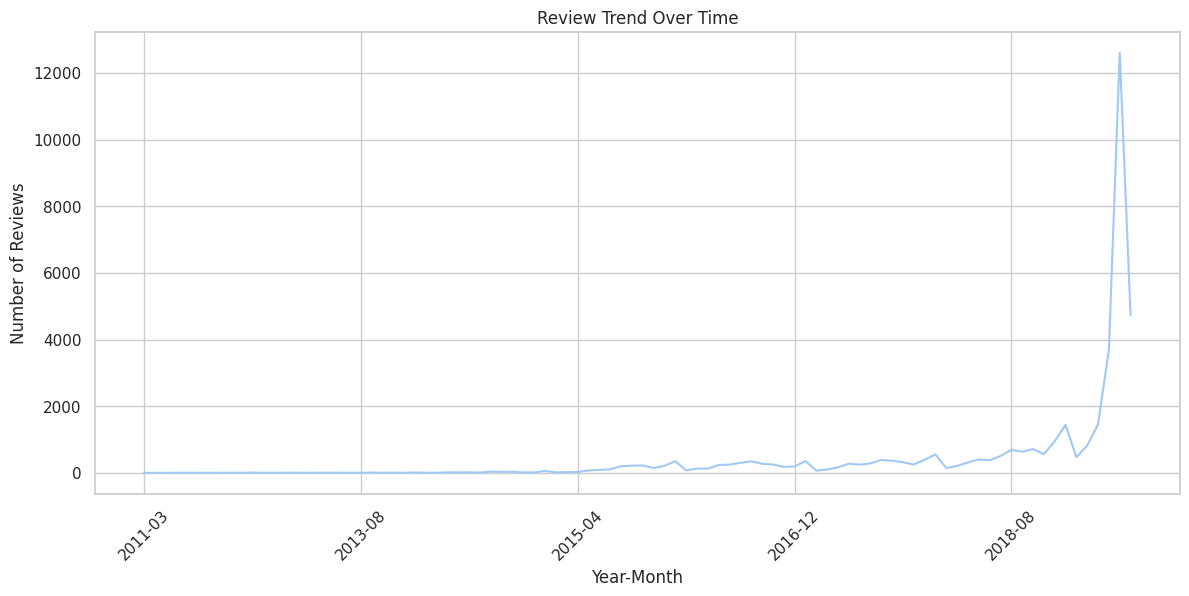

In [46]:
trend = new['year_month'].value_counts().sort_index()

plt.figure(figsize=(14,6))
trend.plot()

plt.title('Review Trend Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.show()

 **Analysis: Market Growth & Seasonality**
* **Observation:** There is an exponential increase in review activity leading into 2019, with clear seasonal spikes.
* **Strategic Value:** The platform's rapid growth suggests NYC was reaching peak maturity pre-2020. Hosts should use these peaks to implement "Peak Season" premium pricing.

 **Univariate Summary & Transition**
Through individual variable analysis, we have established that the "Average" NYC Airbnb listing is:
1.  Priced between **\$50 - \$175**.
2.  Located in **Manhattan or Brooklyn**.
3.  An **Entire Home** or **Private Room**.
4.  Managed by an **individual host** with a single property.

**Next Step:** We will now explore how these variables interact—specifically, how **Location** and **Room Type** directly dictate the **Price**.


#### 3.2 Bivariate

Text(0, 0.5, 'Price')

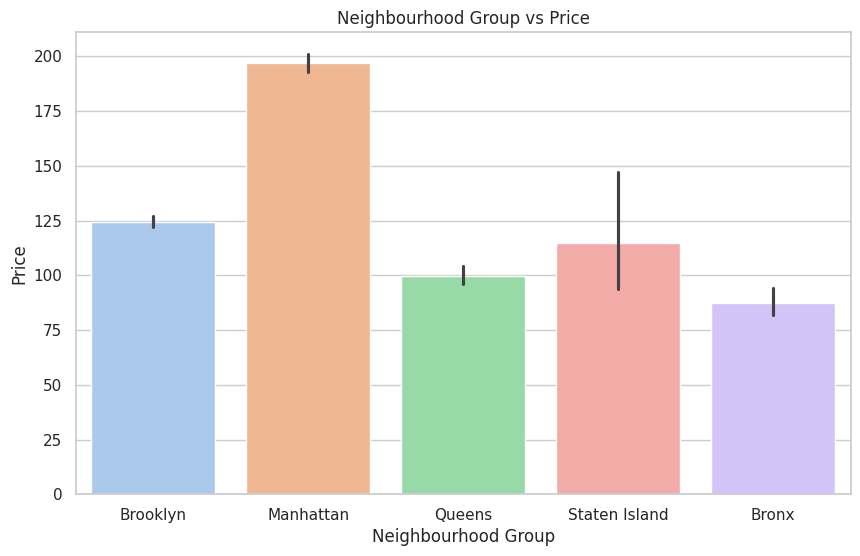

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(x=data.neighbourhood_group,y=data.price,hue=data.neighbourhood_group,estimator=np.mean)
plt.title('Neighbourhood Group vs Price')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Price')

**Analysis: Regional Price Benchmarking**
* **Observation:** Manhattan maintains the highest price floor and ceiling, while Brooklyn follows closely. Interestingly, Queens and Staten Island show similar median pricing despite geographic differences.
* **Strategic Value:** Manhattan is a premium-inelastic market. For travelers, the Bronx represents the best "value-for-money" destination, offering the lowest average rates with accessible transit.

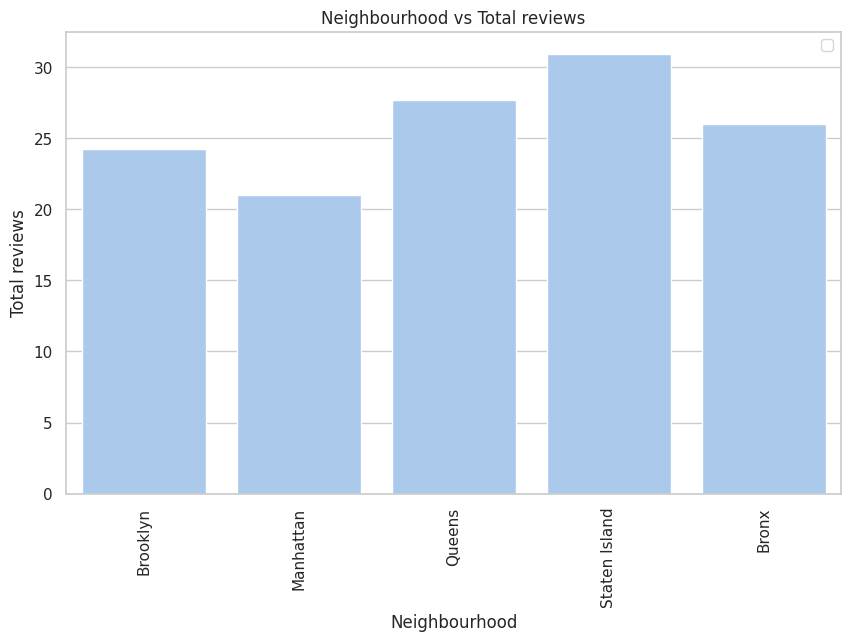

In [48]:
plt.figure(figsize=(10,6))
sns.barplot(x=data.neighbourhood_group,y=data.number_of_reviews,ci=None)
plt.title('Neighbourhood vs Total reviews')
plt.xlabel('Neighbourhood')
plt.ylabel('Total reviews')
plt.legend(loc='upper right')
plt.xticks(rotation=90)
plt.show()

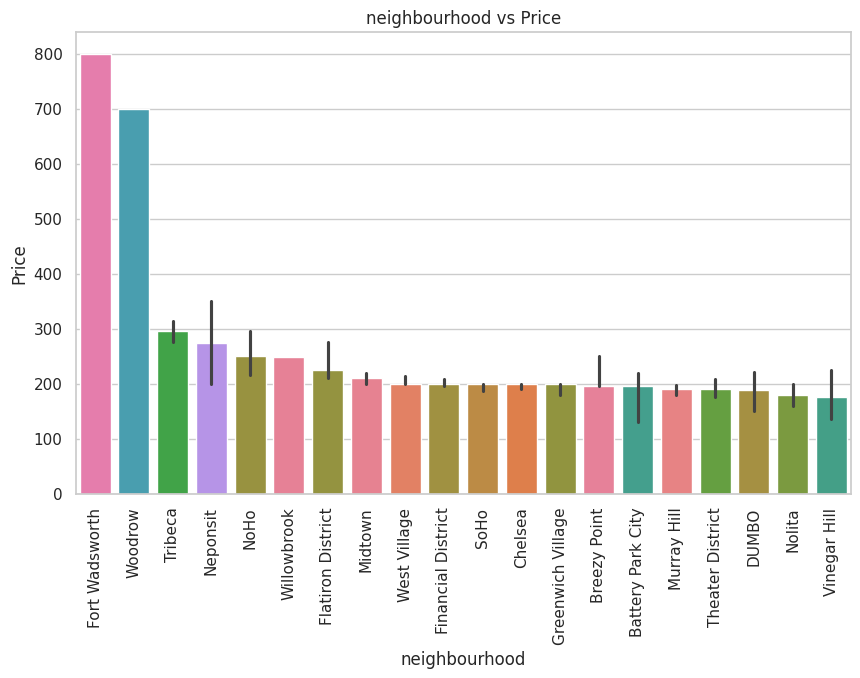

In [49]:
plt.figure(figsize=(10,6))
sns.barplot(x=data.neighbourhood,y=data.price,hue=data.neighbourhood,order=data.groupby('neighbourhood')['price'].median().sort_values(ascending=False).index[:20],estimator=np.median)
plt.title('neighbourhood vs Price')
plt.xlabel('neighbourhood')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.show()

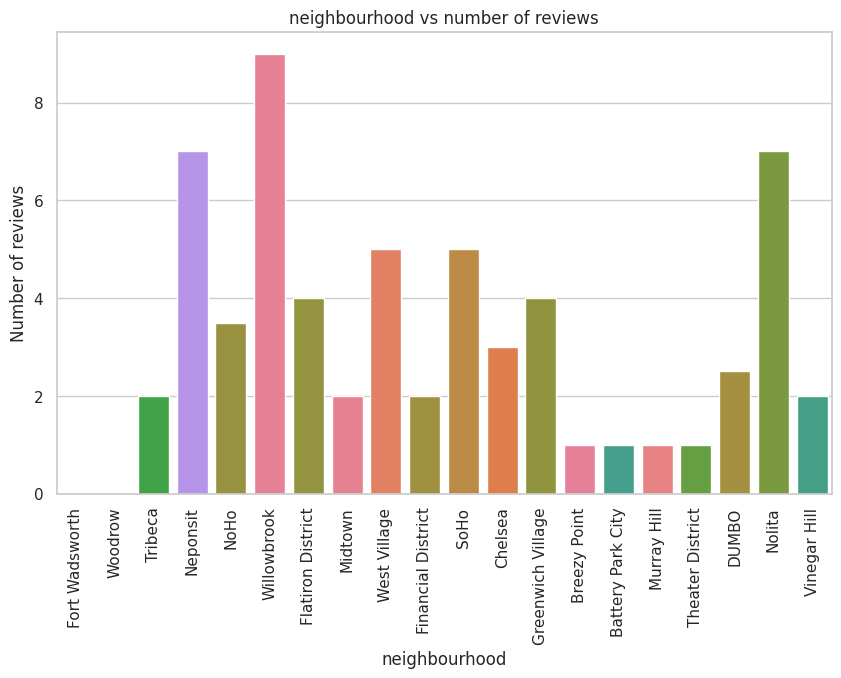

In [50]:
plt.figure(figsize=(10,6))
sns.barplot(x=data.neighbourhood,y=data.number_of_reviews,hue=data.neighbourhood,ci=None,
            order=data.groupby('neighbourhood')['price'].median().sort_values(ascending=False).index[:20],estimator=np.median)
plt.title('neighbourhood vs number of reviews')
plt.xlabel('neighbourhood')
plt.ylabel('Number of reviews')
plt.xticks(rotation=90)
plt.show()

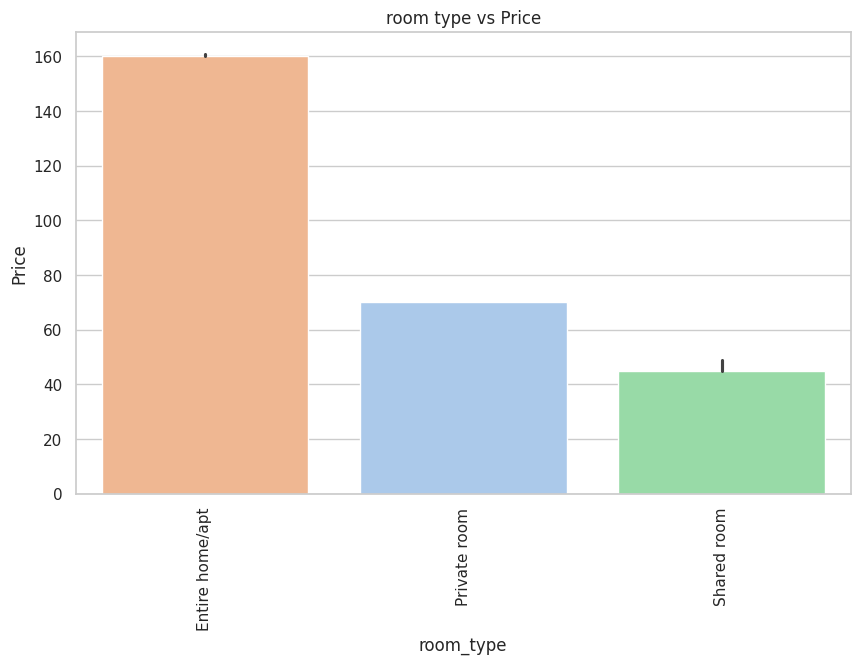

In [51]:
plt.figure(figsize=(10,6))
sns.barplot(x=data.room_type,y=data.price,hue=data.room_type,order=data.groupby('room_type')['price'].median().sort_values(ascending=False).index,estimator=np.median)
plt.title('room type vs Price')
plt.xlabel('room_type')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.show()

**Analysis: Revenue Potential by Property Type**
* **Observation:** Entire homes/apartments command a ~50% premium over private rooms. Shared rooms are priced at a baseline that rarely fluctuates.
* **Strategic Value:** If the goal is ROI, "Entire Home" listings are the most lucrative. However, "Private Rooms" in Manhattan often price higher than "Entire Homes" in the Bronx, proving that **Location > Room Type**.

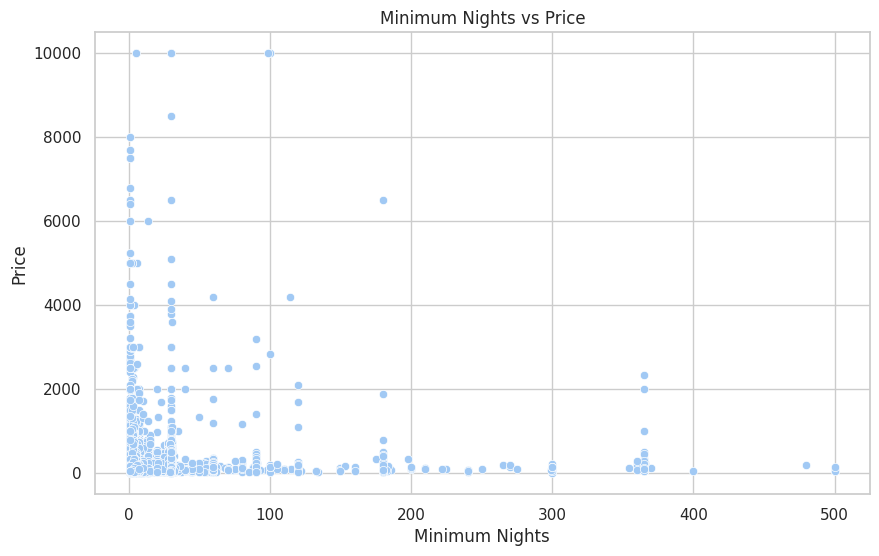

In [52]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=data.minimum_nights,y=data.price)
plt.title('Minimum Nights vs Price')
plt.xlabel('Minimum Nights')
plt.ylabel('Price')
plt.show()

 **Analysis: Stay Duration vs. Valuation**
* **Observation:** High-priced listings (>$1000) almost exclusively feature low minimum-night requirements (1-3 nights).
* **Strategic Value:** NYC's luxury market is driven by short-term "experience" travelers. Listings with long minimum stays (30+ days) generally experience a "bulk discount" effect, reducing daily revenue.

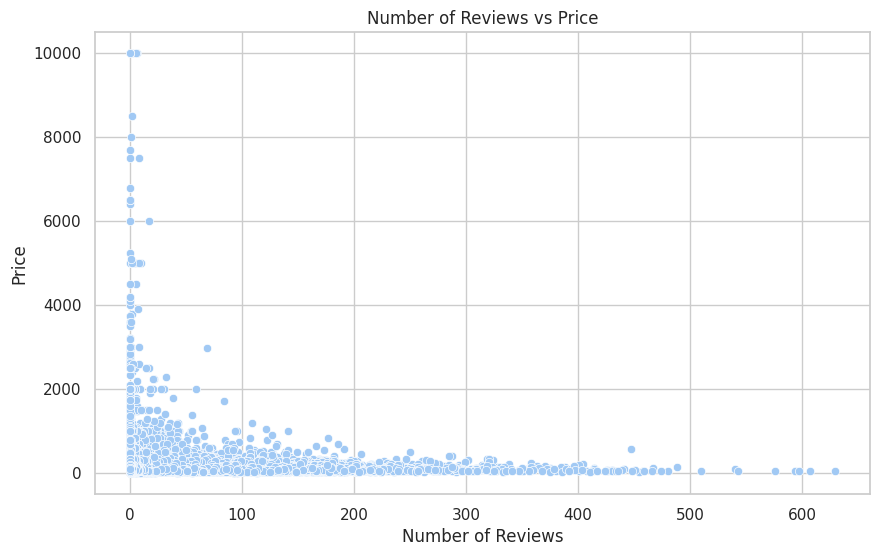

In [53]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=data.number_of_reviews,y=data.price)
plt.title('Number of Reviews vs Price')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.show()

**Analysis: The "Trust vs. Price" Paradox**
* **Observation:** The most expensive listings often have *fewer* reviews, while mid-range listings ($100-$300) show the highest review density.
* **Strategic Value:** Ultra-luxury guests are less likely to leave public reviews, or these properties have lower turnover. For a new host, staying in the "Mid-Range" is the fastest way to build the social proof (reviews) needed for long-term ranking.

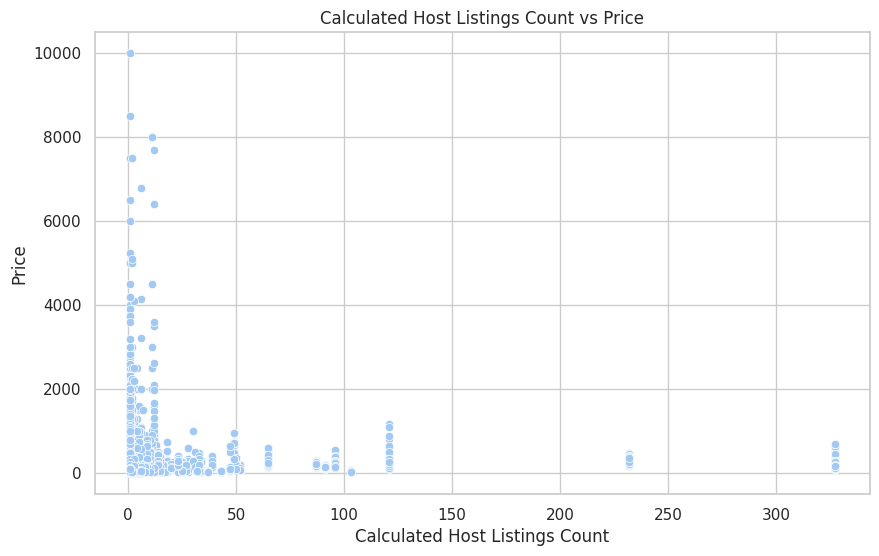

In [54]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=data.calculated_host_listings_count,y=data.price)
plt.title('Calculated Host Listings Count vs Price')
plt.xlabel('Calculated Host Listings Count')
plt.ylabel('Price')
plt.show()

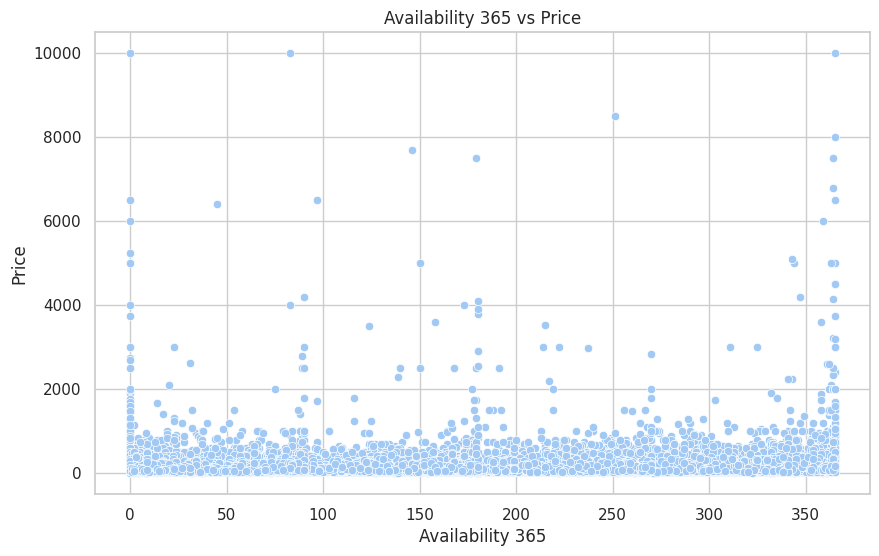

In [55]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=data.availability_365,y=data.price)
plt.title('Availability 365 vs Price')
plt.xlabel('Availability 365')
plt.ylabel('Price')
plt.show()

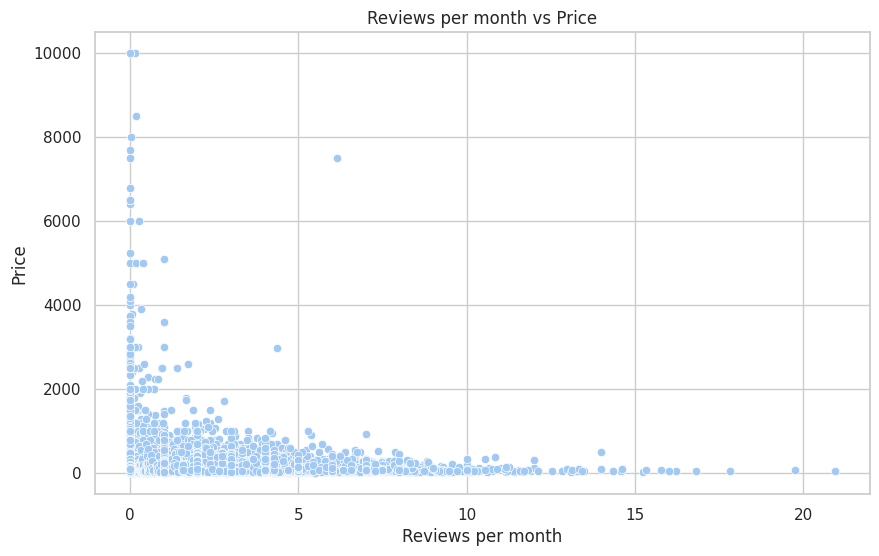

In [56]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=data.reviews_per_month,y=data.price)
plt.title('Reviews per month vs Price')
plt.xlabel('Reviews per month')
plt.ylabel('Price')
plt.show()

#### 3.3 Multivariate

In [57]:
data.number_of_reviews.describe()

,number_of_reviews
count,48888.000000
mean,23.272357
std,44.548479
min,0.000000
25%,1.000000
50%,5.000000
75%,24.000000
max,629.000000


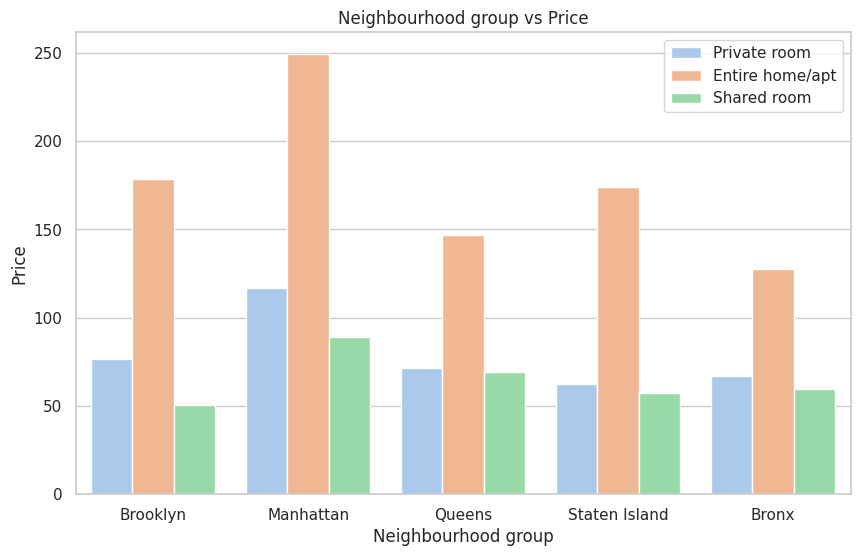

In [58]:
plt.figure(figsize=(10,6))
sns.barplot(x=data.neighbourhood_group,y=data.price,hue = data.room_type,ci=None)
plt.title('Neighbourhood group vs Price')
plt.xlabel('Neighbourhood group')
plt.ylabel('Price')
plt.legend(loc='upper right')
plt.show()

**Multi-Factor Analysis: The Price Hierarchy**
* **Core Finding:** The price gap between an "Entire Home" and a "Private Room" is widest in Manhattan. In the Bronx, the price difference is marginal.
* **Strategic Value:** In premium boroughs, privacy is a luxury travelers pay heavily for. In outer boroughs, travelers are more price-sensitive, and the "type" of room matters less than the total cost.

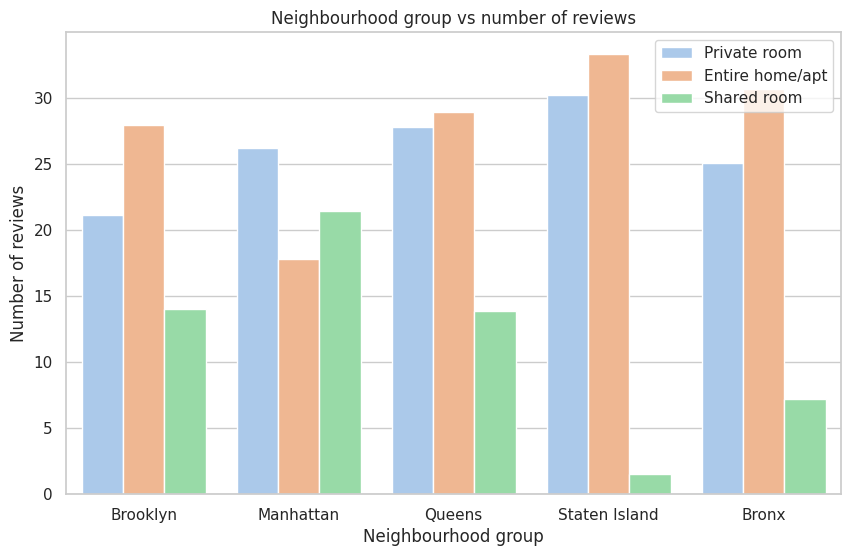

In [59]:
plt.figure(figsize=(10,6))
sns.barplot(x=data.neighbourhood_group,y=data.number_of_reviews,hue = data.room_type,ci=None)
plt.title('Neighbourhood group vs number of reviews')
plt.xlabel('Neighbourhood group')
plt.ylabel('Number of reviews')
plt.legend(loc='upper right')
plt.show()

**Analysis: Regional Popularity & Guest Engagement**
* **Observation:** While Manhattan has the most listings, Brooklyn often competes or leads in total review volume.
* **Strategic Value:** High review counts are a proxy for "Occupancy Rate." This suggests that Brooklyn listings may have higher turnover or more engaged guests compared to Manhattan, making it a high-yield area for active hosts.

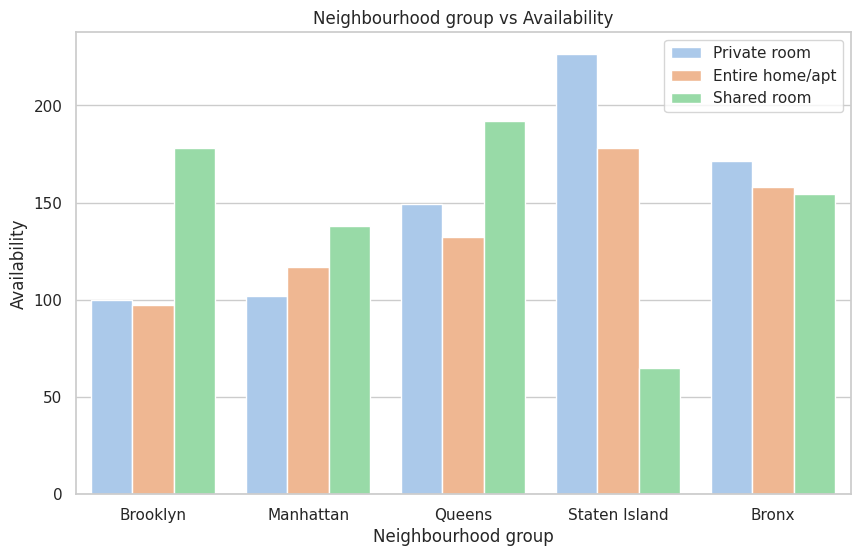

In [60]:
plt.figure(figsize=(10,6))
sns.barplot(x=data.neighbourhood_group,y=data.availability_365,hue = data.room_type,ci = None)
plt.title('Neighbourhood group vs Availability')
plt.xlabel('Neighbourhood group')
plt.ylabel('Availability')
plt.legend(loc='upper right')
plt.show()

In [61]:
new['review_bins'] = pd.cut(data.number_of_reviews,bins=[0,100,200,300,400,500,600],labels=['0-100','100-200','200-300','300-400','400-500','500-600'])


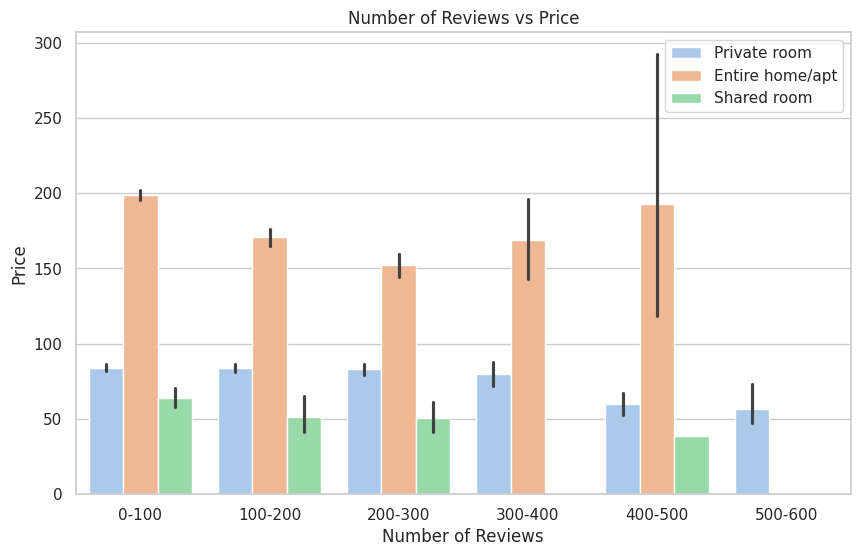

In [62]:
plt.figure(figsize=(10,6))
sns.barplot(x=new.review_bins,y=data.price,hue = data.room_type)
plt.title('Number of Reviews vs Price')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.legend(loc='upper right')
plt.show()

**Multi-Factor Analysis: Does 'Social Proof' Increase Price?**
* **Observation:** Listings in the '0-100' review bin show a wide price variance, while listings with '400-600' reviews tend to have more stable, mid-range pricing.
* **Strategic Value:** This indicates that "Social Proof" (high review counts) doesn't necessarily allow you to charge infinite premiums; rather, it provides **price stability**. High-review listings find a "market-clearing price" and stay there to maintain high occupancy.

In [63]:
data.columns

Index(['id', 'host_id', 'neighbourhood_group', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

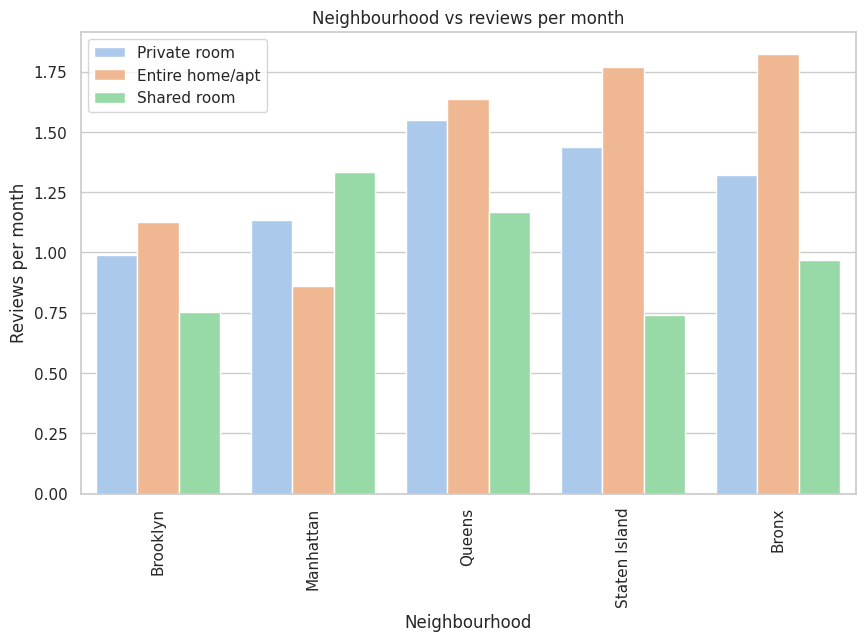

In [64]:
## neighbourhood vs reviews per month vs room type
plt.figure(figsize=(10,6))
sns.barplot(x=data.neighbourhood_group,y=data.reviews_per_month,hue = data.room_type,ci=None)
plt.title('Neighbourhood vs reviews per month')
plt.xlabel('Neighbourhood')
plt.ylabel('Reviews per month')
plt.legend(loc='upper left')
plt.xticks(rotation=90)
plt.show()


In [65]:
new['availability bin'] = pd.cut(data.availability_365,bins=[0,50,100,150,200,250,300,350,400],labels=['0-50','50-100','100-150','150-200','200-250','250-300','300-350','350-400'])

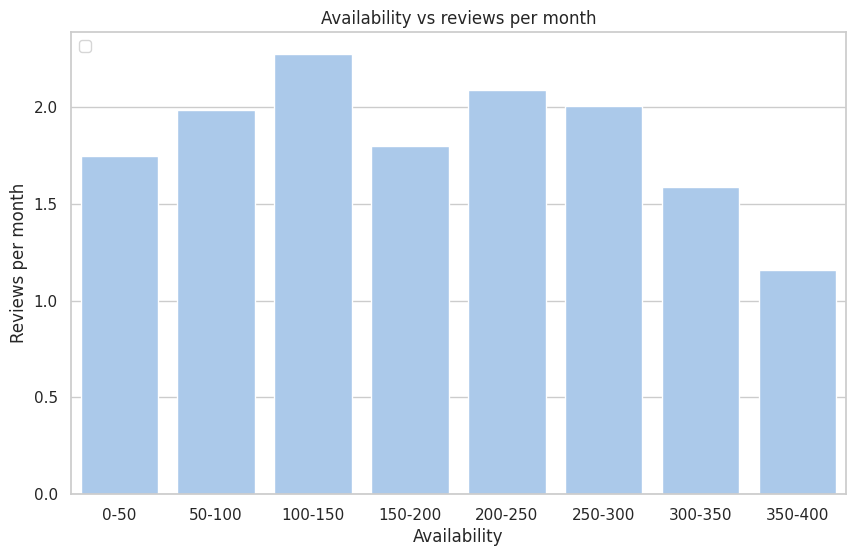

In [66]:
## Availability and reviews per month

plt.figure(figsize=(10,6))
sns.barplot(x=new['availability bin'],y=data.reviews_per_month,ci=None)
plt.title('Availability vs reviews per month')
plt.xlabel('Availability')
plt.ylabel('Reviews per month')
plt.legend(loc='upper left')
plt.show()

**Efficiency Analysis: Occupancy vs. Engagement**
* **Observation:** Listings with **low-to-mid availability (50-150 days)** tend to have higher "Reviews per Month" than those available 365 days a year.
* **Strategic Value:** This suggests that "Full-time" Airbnb listings might be professionally managed/canned experiences, whereas "Part-time" listings (possibly primary residences) garner more organic engagement and higher review velocity.

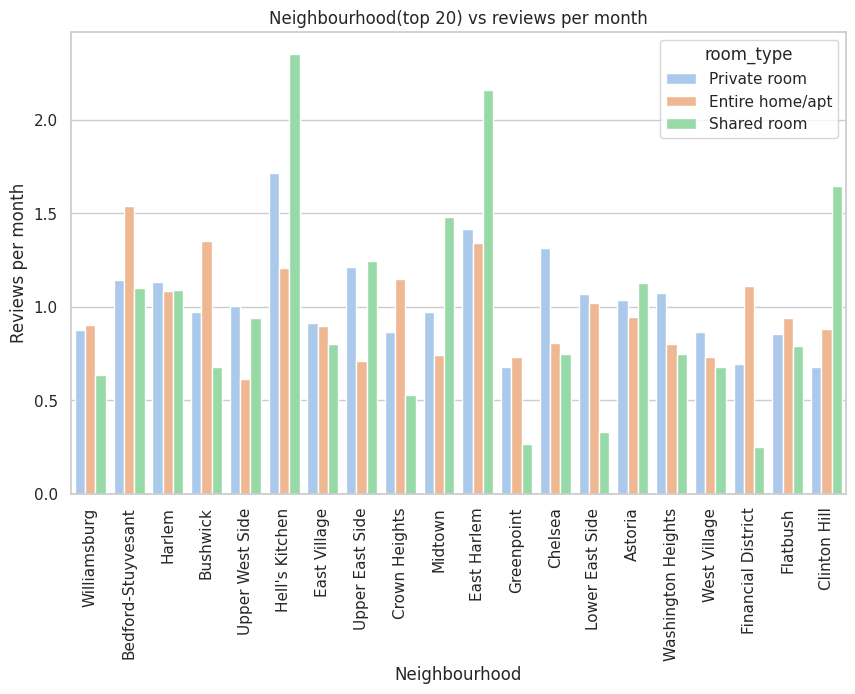

In [67]:
## neighbour hood and reviews per month
plt.figure(figsize=(10,6))
sns.barplot(x=data.neighbourhood,y=data.reviews_per_month,ci=None,order = data.neighbourhood.value_counts().index[:20],hue=data.room_type)
plt.title('Neighbourhood(top 20) vs reviews per month')
plt.xlabel('Neighbourhood')
plt.ylabel('Reviews per month')
plt.xticks(rotation=90)
plt.show()

**Analysis: Identifying "Trending" Neighborhoods**
* **Observation:** Certain neighborhoods in the Top 20 list show significantly higher 'Reviews per Month' than others, regardless of their total listing count.
* **Strategic Value:** These are the "Trending" zones. For a new host, entering a neighborhood with high review velocity is better than entering one with just a high number of listings, as it indicates active, consistent traveler demand.

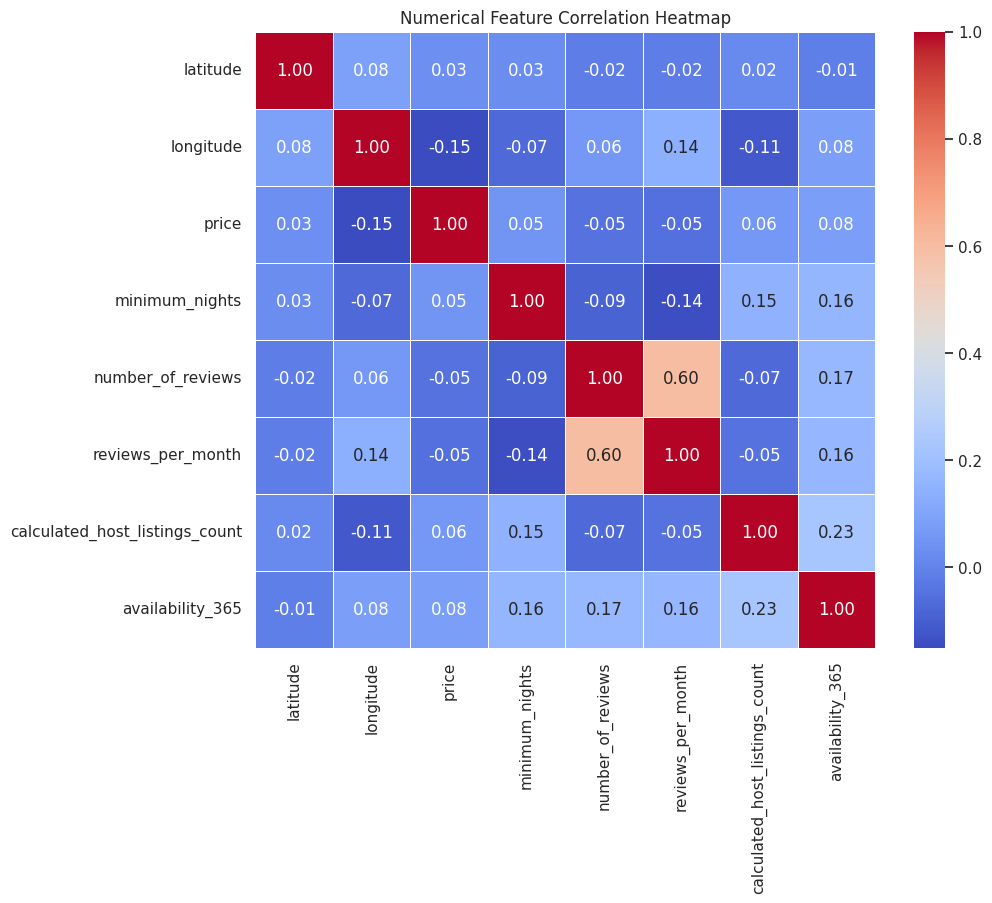

In [68]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation = data[num_col].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

## 4. Final Verdict: NYC Airbnb Market 2019

###  Market Summary
The NYC market is highly concentrated and driven by the **Manhattan-Brooklyn axis**. While the market is saturated with "Single-Listing" hosts, professional "Power Hosts" dominate the inventory in high-traffic areas like the Theater District and Financial District.

###  Key Recommendations
1.  **For New Hosts:** Target **Brooklyn or Queens**. These areas provide a high review-to-price ratio, allowing you to build social proof faster than the hyper-competitive Manhattan market.
2.  **For Investors:** Focus on **Entire Homes**. The data shows a significant "Privacy Premium" that guests are willing to pay, especially in Manhattan.
3.  **Pricing Strategy:** Maintain a **1-3 night minimum stay**. The scatter analysis shows that listings with high minimum stays lose out on the high-margin "Weekend Tourist" segment.
4.  **Growth Lever:** Focus on **Review Velocity**. Listings with higher "Reviews per Month" show more consistent pricing power than those with just a high "Total Review" count.

## 5. Project Limitations & Future Scope

While this EDA provides a deep dive into the NYC Airbnb market, the following limitations should be noted for a comprehensive understanding:

* **Temporal Constraints**: The dataset is from **2019**. The global travel landscape and NYC short-term rental regulations have changed significantly post-2020.
* **Missing Descriptive Data**: We lack information on **amenities** (WiFi, AC, Parking) and **guest demographics**, which are often high-impact drivers for price and review volume.
* **Sentiment Gap**: This analysis relies on the *number* of reviews and *reviews per month* as proxies for popularity. A **Sentiment Analysis** of the actual review text would provide a more nuanced view of guest satisfaction.
* **Price Fluctuations**: The 'price' listed is a static snapshot. Real-world Airbnb pricing is dynamic and changes based on holidays, events, and seasonality, which is not captured in this static CSV.

**Future Work:** > Integrating an updated 2024-2025 dataset and performing a "Pre vs. Post" comparative analysis would be the logical next step for this project.